In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
exp_density = {280: 0.99987, 290: 0.99877, 300: 0.99657, 310: 0.99342, 320: 0.98945, 330: 0.98479}

In [3]:
# # mace_small_280 = pd.read_csv('output/wat_mace_small/wat_280_npt_density.csv')

temperatures = [280, 290, 300, 310, 320, 330]
final_part_size = 0.5

grace_2l_small = dict()
grace_2l_small_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_small_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_small[temp] = pd.read_csv(path)
        grace_2l_small_mean[temp] = grace_2l_small[temp][int(len(grace_2l_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_small[temp] = None
        grace_2l_small_mean[temp] = None



grace_2l_medium = dict()
grace_2l_medium_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_medium_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_medium[temp] = pd.read_csv(path)
        grace_2l_medium_mean[temp] = grace_2l_medium[temp][int(len(grace_2l_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_medium[temp] = None
        grace_2l_medium_mean[temp] = None


grace_2l_large = dict()
grace_2l_large_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_large_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_large[temp] = pd.read_csv(path)
        grace_2l_large_mean[temp] = grace_2l_large[temp][int(len(grace_2l_large[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_large[temp] = None
        grace_2l_large_mean[temp] = None


mace_small = dict()
mace_small_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_small/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_small[temp] = pd.read_csv(path)
        mace_small_mean[temp] = mace_small[temp][int(len(mace_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_small[temp] = None
        mace_small_mean[temp] = None

mace_medium = dict()
mace_medium_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_medium/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_medium[temp] = pd.read_csv(path)
        mace_medium_mean[temp] = mace_medium[temp][int(len(mace_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_medium[temp] = None
        mace_medium_mean[temp] = None

In [4]:

# Build a table from all mean dictionaries
df = pd.DataFrame({
    "Temperature_K": temperatures,
    "Experimental": [exp_density[t] for t in temperatures],
    "GRACE (2L-S)": [grace_2l_small_mean[t] for t in temperatures],
    "GRACE (2L-M)": [grace_2l_medium_mean[t] for t in temperatures],
    "GRACE (2L-L)": [grace_2l_large_mean[t] for t in temperatures],
    "MACE (S)": [mace_small_mean[t] for t in temperatures],
    "MACE (M)": [mace_medium_mean[t] for t in temperatures],
})

# Save to CSV
df.to_csv("all_density_means.csv", index=False)




In [5]:
df = pd.read_csv("all_density_means.csv")

/tmp/ipykernel_2147869/767478927.py:21: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(temps, values,


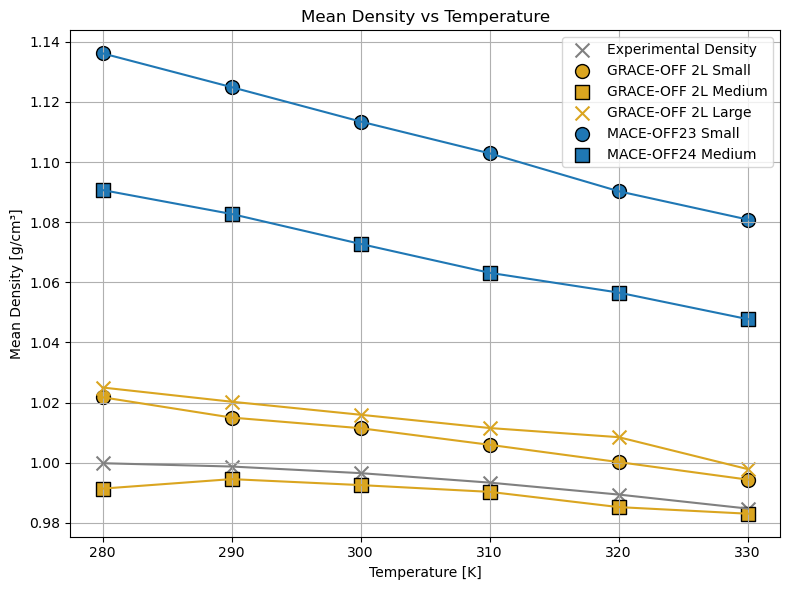

In [10]:
# --- Read the CSV ---
mean_data = pd.read_csv("all_density_means.csv")

# --- Define styles for each column (except Temperature) ---
plot_styles = {
    "Experimental": {"color": "gray", "marker": "x", "label": "Experimental Density"},
    "GRACE (2L-S)": {"color": "goldenrod", "marker": "o", "label": "GRACE-OFF 2L Small"},
    "GRACE (2L-M)": {"color": "goldenrod", "marker": "s", "label": "GRACE-OFF 2L Medium"},
    "GRACE (2L-L)": {"color": "goldenrod", "marker": "x", "label": "GRACE-OFF 2L Large"},
    "MACE (S)": {"color": "tab:blue", "marker": "o", "label": "MACE-OFF23 Small"},
    "MACE (M)": {"color": "tab:blue", "marker": "s", "label": "MACE-OFF24 Medium"},
}

plt.figure(figsize=(8,6))

# --- Loop over columns to plot ---
for col, style in plot_styles.items():
    temps = mean_data["Temperature_K"]
    values = mean_data[col]
    
    plt.scatter(temps, values,
                color=style["color"],
                marker=style["marker"],
                edgecolor='k' if col != "Experimental" else None,
                s=100,
                label=style["label"])
    
    plt.plot(temps, values, color=style["color"])

# --- Final plot formatting ---
plt.xticks([280, 290, 300, 310, 320, 330])
plt.xlabel('Temperature [K]')
plt.ylabel('Mean Density [g/cm³]')
plt.title('Mean Density vs Temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('density_vs_temperature.png', dpi=300)
plt.show()


In [11]:
def get_data(model_type: str, size: str, temp: int) -> pd.DataFrame:
    path = f'output/{model_type}_wat_grace_{size}_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"File not found: {path}")
        return None

grace = get_data('2l', 'medium', 310)
grace

,time_ps,volume_A3,density_g_cm3,ns_per_day
0,0.0,17169.518,0.99660,NaN
1,0.1,17122.236,0.99935,0.25907
2,0.2,16966.652,1.00852,0.38599
3,0.3,16808.938,1.01798,0.46085
4,0.4,16759.809,1.02096,0.51023
...,...,...,...,...
1996,199.6,17357.186,0.98583,0.76558
1997,199.7,17351.813,0.98613,0.76558
1998,199.8,17368.920,0.98516,0.76558
1999,199.9,17364.669,0.98540,0.76559
